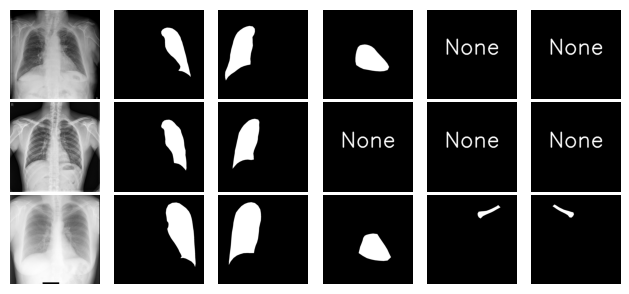

In [1]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
import json 
import os 

sample_images = [
    '1256842362861431725328351539259305635_u1qifz.png',
    'CHNCXR_0226_0.png',
    'JPCNN018.png']

# annotations are the same path but replace images with landmarks and .png with .json
annotations = [img.replace('.png', '.json') for img in sample_images]

c = 0
for img_path, ann_path in zip(sample_images, annotations):
    # read image
    img = cv2.imread(os.path.join('Dataset/CXRAY/Landmarks_3_10/images', img_path), 0)

    # read annotation
    with open(os.path.join('Dataset/CXRAY/Landmarks_3_10/landmarks', ann_path), 'r') as f:
        ann = json.load(f)
    
    plt.subplot(3, 6, 1 + c*6)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    for organ in ['1', '2', '3', '4', '5']:
        if organ in ann:
            plt.subplot(3, 6, int(organ)+1 + c*6)
            # create a blank image and fill the contour of the organ
            blank = np.zeros_like(img)
            points = np.array(ann[organ])
            cv2.fillPoly(blank, [points], (255))
            plt.imshow(blank, cmap='gray')
            plt.axis('off')
        else:
            plt.subplot(3, 6, int(organ)+1 + c*6)
            blank = np.zeros_like(img)
            # write missing bold and big in the middle of the image
            cv2.putText(blank, 'None', (200, blank.shape[0]//2), cv2.FONT_HERSHEY_SIMPLEX, 8, (255), 15, cv2.LINE_AA)
            plt.imshow(blank, cmap='gray')
            plt.axis('off')

    c += 1
# subplot adjustment
plt.subplots_adjust(wspace=0.1, hspace=-0.8)
plt.tight_layout()
# store with transparent background
plt.savefig('landmarks_visualization.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [11]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import json
import os

# Create output directory
output_dir = 'figure1_images'
os.makedirs(output_dir, exist_ok=True)

sample_images = [
    '1256842362861431725328351539259305635_u1qifz.png',
    'CHNCXR_0226_0.png',
    'JPCNN018.png'
]

annotations = [img.replace('.png', '.json') for img in sample_images]

# Organ names for file naming
organ_names = {
    '1': 'left_lung',
    '2': 'right_lung', 
    '3': 'heart',
    '4': 'left_clavicle',
    '5': 'right_clavicle'
}

# Organ groups for masks (3 groups instead of 5 individual)
organ_groups = {
    'lungs': ['1', '2'],  # left_lung + right_lung
    'heart': ['3'],
    'clavicles': ['4', '5']  # left_clavicle + right_clavicle
}

group_names = ['lungs', 'heart', 'clavicles']

# Colormap for contours
colors = cm.get_cmap('tab10', 10)

for idx, (img_path, ann_path) in enumerate(zip(sample_images, annotations)):
    # Read image
    img = cv2.imread(os.path.join('Dataset/CXRAY/Landmarks_3_10/images', img_path), 0)
    
    # Read annotation
    with open(os.path.join('Dataset/CXRAY/Landmarks_3_10/landmarks', ann_path), 'r') as f:
        ann = json.load(f)
    
    # Create sample-specific folder
    sample_folder = os.path.join(output_dir, f'sample_{idx+1}')
    os.makedirs(sample_folder, exist_ok=True)
    
    # Save original image
    plt.figure(figsize=(4, 4), dpi=150)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(os.path.join(sample_folder, 'original.png'), 
                bbox_inches='tight', pad_inches=0, transparent=True)
    plt.close()
    
    # Save grouped organ masks (3 groups)
    for group_name in group_names:
        plt.figure(figsize=(4, 4), dpi=150)
        
        organ_ids = organ_groups[group_name]
        has_any_organ = any(organ_id in ann for organ_id in organ_ids)
        
        if has_any_organ:
            # Create combined mask for all organs in this group
            blank = np.zeros_like(img)
            for organ_id in organ_ids:
                if organ_id in ann:
                    points = np.array(ann[organ_id])
                    cv2.fillPoly(blank, [points], (255))
            
            plt.imshow(blank, cmap='gray')
            plt.axis('off')
            plt.tight_layout(pad=0)
            plt.savefig(os.path.join(sample_folder, f'{group_name}_mask.png'),
                       bbox_inches='tight', pad_inches=0, transparent=True)
        else:
            # Create "None" placeholder
            blank = np.zeros_like(img)
            cv2.putText(blank, 'None', (img.shape[1]//4, img.shape[0]//2), 
                       cv2.FONT_HERSHEY_SIMPLEX, 3, (255), 8, cv2.LINE_AA)
            plt.imshow(blank, cmap='gray')
            plt.axis('off')
            plt.tight_layout(pad=0)
            plt.savefig(os.path.join(sample_folder, f'{group_name}_none.png'),
                       bbox_inches='tight', pad_inches=0, transparent=True)
        
        plt.close()
    
    # Save contour visualization (all organs on original image)
    plt.figure(figsize=(4, 4), dpi=150)
    plt.imshow(img, cmap='gray', alpha=0.7)
    
    for organ_idx, (organ_id, organ_name) in enumerate(organ_names.items()):
        if organ_id in ann:
            points = np.array(ann[organ_id])
            color = colors(organ_idx)[:3]  # RGB only
            # Draw filled polygon with transparency
            plt.fill(points[:, 0], points[:, 1], 
                    color=color, alpha=0.3)
            # Draw contour
            plt.plot(np.append(points[:, 0], points[0, 0]), 
                    np.append(points[:, 1], points[0, 1]),
                    color=color, linewidth=2)
    
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(os.path.join(sample_folder, 'contours_overlay.png'),
               bbox_inches='tight', pad_inches=0, transparent=True)
    plt.close()
    
    # Save individual organ contours (for extracted contours visualization)
    for organ_idx, (organ_id, organ_name) in enumerate(organ_names.items()):
        if organ_id in ann:
            plt.figure(figsize=(2, 2), dpi=150)
            points = np.array(ann[organ_id])[::25]
            color = colors(organ_idx)
            
            # Plot contour only (no fill)
            plt.scatter(np.append(points[:, 0], points[0, 0]), 
                    np.append(points[:, 1], points[0, 1]),
                    color=color, linewidth=2)
            
            # Set axis limits based on contour bounds
            margin = 50
            plt.xlim(points[:, 0].min() - margin, points[:, 0].max() + margin)
            plt.ylim(points[:, 1].max() + margin, points[:, 1].min() - margin)
            plt.axis('off')
            plt.gca().set_aspect('equal')
            plt.tight_layout(pad=0)
            plt.savefig(os.path.join(sample_folder, f'{organ_name}_contour.png'),
                       bbox_inches='tight', pad_inches=0, transparent=True)
            plt.close()

print(f"Images saved to {output_dir}/")
print("\nGenerated files for each sample:")
print("- original.png: Original X-ray image")
print("- lungs_mask.png: Combined left + right lung mask")
print("- heart_mask.png: Heart mask")
print("- clavicles_mask.png: Combined left + right clavicle mask")
print("- {group}_none.png: 'None' placeholders for missing organ groups")
print("- contours_overlay.png: All organ contours overlaid on image")
print("- {organ}_contour.png: Individual organ contours (for 'Extracted Organ Contours' box)")

/tmp/ipykernel_180587/348520252.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', 10)


Images saved to figure1_images/

Generated files for each sample:
- original.png: Original X-ray image
- lungs_mask.png: Combined left + right lung mask
- heart_mask.png: Heart mask
- clavicles_mask.png: Combined left + right clavicle mask
- {group}_none.png: 'None' placeholders for missing organ groups
- contours_overlay.png: All organ contours overlaid on image
- {organ}_contour.png: Individual organ contours (for 'Extracted Organ Contours' box)


In [3]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import json
import os

# Create output directory
output_dir = 'figure1_correspondences'
os.makedirs(output_dir, exist_ok=True)

sample_images = [
    '1256842362861431725328351539259305635_u1qifz.png',
    'CHNCXR_0226_0.png',
    'JPCNN018.png'
]

annotations = [img.replace('.png', '.json') for img in sample_images]

# Colormap for landmarks (rainbow for easy correspondence matching)
landmark_colormap = cm.get_cmap('hsv')

# Organ names
organ_names = {
    '1': 'left_lung',
    '2': 'right_lung', 
    '3': 'heart',
    '4': 'left_clavicle',
    '5': 'right_clavicle'
}

# Organ colors (tab10)
organ_colors = cm.get_cmap('tab10', 10)

def subsample_landmarks(points, target_count=8):
    """Subsample landmarks uniformly along contour"""
    if len(points) <= target_count:
        return points
    indices = np.linspace(0, len(points)-1, target_count, dtype=int)
    return points[indices]

# Generate per-patient correspondence visualizations
for idx, (img_path, ann_path) in enumerate(zip(sample_images, annotations)):
    img = cv2.imread(os.path.join('Dataset/CXRAY/Landmarks_3_10/images', img_path), 0)
    
    with open(os.path.join('Dataset/CXRAY/Landmarks_3_10/landmarks', ann_path), 'r') as f:
        ann = json.load(f)
    
    patient_folder = os.path.join(output_dir, f'patient_{idx+1}')
    os.makedirs(patient_folder, exist_ok=True)
    
    # Full image with all organ contours and landmarks
    plt.figure(figsize=(6, 6), dpi=150)
    plt.imshow(img, cmap='gray', alpha=0.5)
    
    for organ_idx, (organ_id, organ_name) in enumerate(organ_names.items()):
        if organ_id in ann:
            points = np.array(ann[organ_id])
            color = organ_colors(organ_idx)[:3]
            
            # Draw contour
            plt.plot(np.append(points[:, 0], points[0, 0]), 
                    np.append(points[:, 1], points[0, 1]),
                    color=color, linewidth=3, alpha=0.7)
            
            # Subsample and draw landmarks with correspondence colors
            landmarks = subsample_landmarks(points, target_count=8)
            for lm_idx, lm in enumerate(landmarks):
                lm_color = landmark_colormap(lm_idx / len(landmarks))[:3]
                plt.scatter(lm[0], lm[1], c=[lm_color], s=100, 
                           edgecolors='white', linewidths=2, zorder=10)
    
    plt.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(os.path.join(patient_folder, 'all_organs_with_landmarks.png'),
               bbox_inches='tight', pad_inches=0, transparent=True, dpi=200)
    plt.close()
    
    # Individual organ contours with landmarks
    for organ_idx, (organ_id, organ_name) in enumerate(organ_names.items()):
        if organ_id in ann:
            points = np.array(ann[organ_id])
            color = organ_colors(organ_idx)[:3]
            
            plt.figure(figsize=(3, 3), dpi=150)
            
            # Draw contour
            plt.plot(np.append(points[:, 0], points[0, 0]), 
                    np.append(points[:, 1], points[0, 1]),
                    color=color, linewidth=4)
            
            # Subsample and draw landmarks
            landmarks = subsample_landmarks(points, target_count=8)
            for lm_idx, lm in enumerate(landmarks):
                lm_color = landmark_colormap(lm_idx / len(landmarks))[:3]
                plt.scatter(lm[0], lm[1], c=[lm_color], s=150, 
                           edgecolors='white', linewidths=2, zorder=10)
            
            # Set limits with margin
            margin = 80
            plt.xlim(points[:, 0].min() - margin, points[:, 0].max() + margin)
            plt.ylim(points[:, 1].max() + margin, points[:, 1].min() - margin)
            plt.axis('off')
            plt.gca().set_aspect('equal')
            plt.tight_layout(pad=0)
            plt.savefig(os.path.join(patient_folder, f'{organ_name}_landmarks.png'),
                       bbox_inches='tight', pad_inches=0, transparent=True, dpi=200)
            plt.close()

# Create side-by-side comparison for 2 patients (for demonstrating correspondence)
print("\nGenerating side-by-side correspondence comparison...")

for organ_id, organ_name in organ_names.items():
    # Check if this organ exists in at least 2 samples
    available_samples = []
    for idx, ann_path in enumerate(annotations):
        with open(os.path.join('Dataset/CXRAY/Landmarks_3_10/landmarks', ann_path), 'r') as f:
            ann = json.load(f)
        if organ_id in ann:
            available_samples.append(idx)
    
    if len(available_samples) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=150)
        
        for plot_idx, sample_idx in enumerate(available_samples[:2]):
            ann_path = annotations[sample_idx]
            with open(os.path.join('Dataset/CXRAY/Landmarks_3_10/landmarks', ann_path), 'r') as f:
                ann = json.load(f)
            
            points = np.array(ann[organ_id])
            organ_idx = list(organ_names.keys()).index(organ_id)
            color = organ_colors(organ_idx)[:3]
            
            ax = axes[plot_idx]
            
            # Draw contour
            ax.plot(np.append(points[:, 0], points[0, 0]), 
                   np.append(points[:, 1], points[0, 1]),
                   color=color, linewidth=4)
            
            # Subsample and draw landmarks with same colors
            landmarks = subsample_landmarks(points, target_count=8)
            for lm_idx, lm in enumerate(landmarks):
                lm_color = landmark_colormap(lm_idx / len(landmarks))[:3]
                ax.scatter(lm[0], lm[1], c=[lm_color], s=200, 
                          edgecolors='white', linewidths=2, zorder=10)
                # Add landmark number
                ax.text(lm[0], lm[1], str(lm_idx+1), 
                       fontsize=8, color='white', weight='bold',
                       ha='center', va='center', zorder=11)
            
            # Set limits
            margin = 80
            ax.set_xlim(points[:, 0].min() - margin, points[:, 0].max() + margin)
            ax.set_ylim(points[:, 1].max() + margin, points[:, 1].min() - margin)
            ax.axis('off')
            ax.set_aspect('equal')
            ax.set_title(f'Patient {sample_idx + 1}', fontsize=14, pad=10)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f'{organ_name}_correspondence_comparison.png'),
                   bbox_inches='tight', pad_inches=0.1, transparent=True, dpi=200)
        plt.close()

print(f"\nImages saved to {output_dir}/")
print("\nGenerated files:")
print("- patient_N/all_organs_with_landmarks.png: All organs with color-coded landmarks")
print("- patient_N/{organ}_landmarks.png: Individual organs with landmarks")
print("- {organ}_correspondence_comparison.png: Side-by-side showing same landmarks")
print("\nLandmark colors are consistent across patients to show correspondence!")

/tmp/ipykernel_180587/3331987218.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  landmark_colormap = cm.get_cmap('hsv')
/tmp/ipykernel_180587/3331987218.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  organ_colors = cm.get_cmap('tab10', 10)



Generating side-by-side correspondence comparison...

Images saved to figure1_correspondences/

Generated files:
- patient_N/all_organs_with_landmarks.png: All organs with color-coded landmarks
- patient_N/{organ}_landmarks.png: Individual organs with landmarks
- {organ}_correspondence_comparison.png: Side-by-side showing same landmarks

Landmark colors are consistent across patients to show correspondence!
